# Get Relic Density - scalar mediator

## Thermal relic abundance for DM, where  $\Omega(\chi \chi \to h \to \ell \ell)$

In [4]:
# import utils.colorb_2D as cb2d
# import models.sigma0_xsections as sig0
import sys, os
sys.path.append('../')
import app.models.general_parameters as gp
import app.models.relic_density_calc as ohm
#import app.models.radiative_factorization as hp
#import app.models.pdf_integration as qcd
#import app.utils.colorb_2D as cb2d
# import lhapdf  

In [5]:
import numpy as np

step = 100
dM = 0.01 # TeV
dmx = 0.005 # TeV 
#Mediator mass [Tev] # 
Mmed_min = 0.001
Mmed_max = 5.1
Mmed_arr = np.arange(Mmed_min, Mmed_max, dM)
# DM particle mass [Tev] #
mx_min = 0.001
mx_max = 5.1
mx_arr = np.arange(mx_min, mx_max, dmx)
# Define a grid
Mmed_grid, mx_grid = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot
## CM total energy (14 TeV for HL-LHC)
smax = (3)**2  

# Couplings:
g_ps_psi = 0.25 # pseudo-scalar coupling from Mmed to SM
g_s_psi = 0.25 # scalar coupling from Mmed to SM

g_ps_chi = 1 # pseudo-scalar coupling from Mmed to DM 
g_s_chi = 1 # scalar coupling from Mmed to DM

## Define python functions 

For the decays and cross-sections from the scalar mediator

In [6]:
# ↑ Copy from the last output and do some tweaks

import numpy as np
import numba as nb
np.seterr(invalid='ignore')

@np.vectorize                     
def scalar_mediator_decay(
                          M_med: float | np.ndarray = np.nan,
                          m_f: float | np.ndarray = np.nan,
                          g_s_psi: float | np.ndarray = np.nan,
                          dm_type: str = 'fermion'
                          ) -> float | np.ndarray:
    
    if dm_type == 'scalar':
        return g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)/(np.pi*M_med)
    
    elif dm_type == 'fermion':

        return (1/16)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**2 - 4*m_f**2)/(np.pi*M_med)
    
    elif dm_type == 'vector':
        return (1/64)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**4 - 8*M_med**2*m_f**2 + 16*m_f**4)/(np.pi*M_med*m_f**4)
    
    elif dm_type == 'sm':
        Nf = 18
        return Nf * (1/16)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**2 - 4*m_f**2)/(np.pi*M_med)
    
    else:
        raise Exception



@np.vectorize
def scalar_mediator_xsec(
                          s : float | np.ndarray = np.nan,
                          M_med: float | np.ndarray = np.nan,
                          m_f: float | np.ndarray = np.nan,
                          g_s_psi: float | np.ndarray = np.nan,
                          g_s_chi: float | np.ndarray = np.nan,
                          g_ps_psi: float | np.ndarray = np.nan,
                          g_ps_chi: float | np.ndarray = np.nan,
                          dm_type: str = "",
                          ) -> float | np.ndarray:
    
    
    g_ps_psi = g_s_psi # Equal couplings for scalar and pseudo-scalar mediators
    g_ps_chi = g_s_chi # Equal couplings for scalar and pseudo-scalar mediators
    Bi = scalar_mediator_decay(M_med, m_f, g_ps_psi, dm_type) # Initial states branching ratio
    Bf = scalar_mediator_decay(M_med, m_f, g_ps_psi, dm_type) # Final states branching ratio
    
    Gamma = Bi + Bf # Gamma Decay as the sum of the branching ratios
    
    if dm_type == 'scalar':
        return 16*g_s_chi**2*(g_ps_psi**2 + g_s_psi**2)*np.sqrt(-4*m_f**2 + s)/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))
    
    elif dm_type == 'fermion':
        return (1/2)*np.sqrt(-4*m_f**2 + s)*(-4*g_s_chi**2*m_f**2*(g_ps_psi**2 + g_s_psi**2) + s*(g_ps_chi**2*g_ps_psi**2 + g_ps_chi**2*g_s_psi**2 + g_ps_psi**2*g_s_chi**2 + g_s_chi**2*g_s_psi**2))/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))

    elif dm_type == 'vector':
        return (3/4)*g_s_chi**2*(g_ps_psi**2 + g_s_psi**2)*np.sqrt(-4*m_f**2 + s)/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))

    else:
        raise Exception 
        


## Set general parameters

In [7]:
step = 100
dM = 0.01 # TeV
dmx = 0.005 # TeV 
#Mediator mass [Tev] # 
Mmed_min = 0.001
Mmed_max = 5.1
Mmed_arr = np.arange(Mmed_min, Mmed_max, dM)
# DM particle mass [Tev] #
mx_min = 0.001
mx_max = 5.1
mx_arr = np.arange(mx_min, mx_max, dmx)
# Define a grid
Mmed_grid, mx_grid = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot
## CM total energy (14 TeV for HL-LHC)
smax = (3)**2  

# Couplings:
g_ps_psi = 0.25 # pseudo-scalar coupling from Mmed to SM
g_s_psi = 0.25 # scalar coupling from Mmed to SM

g_ps_chi = 1 # pseudo-scalar coupling from Mmed to DM 
g_s_chi = 1 # scalar coupling from Mmed to DM


In [8]:
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorb
from matplotlib import colors
from mpl_toolkits.axes_grid1 import ImageGrid


results_dict = {}
brn = 0.3894*10**6 

def plot_simple_2d(Mmed_grid, mx_grid, results, plt_title=''):

        fig = plt.figure(figsize=(10, 10))
        ax = ImageGrid(fig, 111,          # as in plt.subplot(111)
                nrows_ncols=(1,1),
                axes_pad=(0.30, 0.0),
                share_all=True,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="5%",
                cbar_pad=0.10,
                aspect=False
                )
                        
        fsize = 10
        im = ax[0].pcolormesh(Mmed_grid, mx_grid, results, norm=colors.LogNorm(), cmap= 'twilight', rasterized=True) ## heat map of xsec
        ax[0].cax.cla()
        cb = colorb.Colorbar(ax[0].cax, im)
        cb.set_label(r'$\sigma_{tot}$ [fb]', fontsize = fsize, loc='top')  ## color bar label 
        ax[0].set_title(plt_title)
        ax[0].tick_params(axis="x")
        ax[0].set_ylim(0, 2.5)

        plt.show()

### Resonance Relic Density

In [11]:
#### Ressonance <sigma.v> - Gondolo 1991, eq 6.13 ####
import scipy.integrate as sp
import numba as nb  #  import vectorize, guvectorize, float64
from functools import partial
import fortran_quad

# RELIC DENSITY CALC ###############################3333

##!! WARNING: sigma must be in TeV^-2 units, not barn ##
h = 67.8 / 100  # constante de hubble reduzida - Planck 2018
M_PLANCK = 1.220910*(10**16)  # Massa de Planck em TeV - PDG 2017
# entropy density/Boltzmann constant, em TeV: 1 cm = 5.06773071*(10^16) TeV^-1
S0 = 2891.1 / (5.06773071*(10**16))**3
# n = 0
GF = 1   # número de graus de liberdade:spin, cor, etc. do candidato de ME -- 1 = escalar, 2 = fermion, 3 = vetorial
GST = 86.25  # g*, Número de partículas relativisticas no periodo do desacoplamento MAX = 106.75, DM101 = 5 GeV < T < 80 GeV, g = 86.25
# usando que 1 cm = 5.06773071*(10^16) TeV^-1
RHO = 1.053672*(10**(-5))*(h**2)*(10**(-3)) / (5.06773071*(10**16))**3
GN = 1 / M_PLANCK**2
# CMB temperature in K to eV, then to TeV
T0 = 2.7255 * (8.61732814974056E-05) / 10E12
GFF = 86.25
planckdata1 = [0.120]  # PLANCK data for \Omega h^2 = 0.120 (2018)
planckdata2 = [[0.120, 1E1000], [0.120]]

# NEW CALCULATION FOR RELIC DENSITY
erroabs = 1
errorel = 1
# from sympy import *

# Implementation of: arXiv:1912.02870v2 and Gondolo 1991


XF = 28  # Following https://arxiv.org/pdf/1703.05703.pdf
# Tf = mx / xf
intlimit = 10

@np.vectorize
def complex_quadrature_fortran(func, a, b):

    def real_func(eps):
        real_result = np.real(complex(func(eps)))
        return real_result

    def imag_func(eps):
        imag_result = np.imag(complex(func(eps)))
        return imag_result

    real_integral = fortran_quad.quad16(real_func, a, b)
    imag_integral = fortran_quad.quad16(imag_func, a, b)

    result_cq = (real_integral + 1j*imag_integral)
    return result_cq

@np.vectorize
def Flzrx_U(u = np.nan, T = np.nan, Mmed = np.nan, mx = np.nan, total_decay = np.nan):
    x = mx/T

    eps = (- np.log(u)) / x
    epsR = ((Mmed**2) - (4*mx**2))/(4*mx**2)
    gamma_r = (Mmed * total_decay) / (4*mx**2)
    zr = epsR + (1j)*gamma_r

    result = ((np.sqrt(1 + eps))/(1 + 2*eps)) * (1/(zr - eps)) * (1/x)
    return result

@np.vectorize
def Flzrx(T, Mmed, mx, total_decay):
    # args=(T,  Mmed, mx, total_decay), complex_func=True)[0]
    Flz_partial = partial(Flzrx_U, T = T, Mmed=Mmed, mx=mx, total_decay=total_decay)
    result_flzrx = np.real(complex((1j/(np.pi)) * complex_quadrature_fortran(Flz_partial, 0, 1)))
    
    return result_flzrx

@np.vectorize
def sigmav_res(T = np.nan, mq = np.nan, Mmed = np.nan, mx = np.nan, gsm = np.nan, gx = np.nan, dm_type = 'fermion'):
    x = mx/T
    # spin configuration
    # Spin of colliding particles: 0 - Scalar, 1/2 - Fermion, 1 - Vector
    # spin_j = 1/2 ## Spin of colliding particles: 0 - Scalar, 1/2 - Fermion, 1 - Vector
    dict_spin = {'scalar': 0, 'fermion': 1/2, 'vector': 1}
    spin_j = dict_spin[dm_type]
    spin_s = 1  # Spin of mediator / ressonance
    W = (2*spin_j + 1)/((2*spin_s + 1)**2)
    

    dm_decay = scalar_mediator_decay(Mmed, mx, gx, dm_type)
    total_decay = dm_decay + scalar_mediator_decay(Mmed, mq, gsm, 'sm')

    epsR = ((Mmed**2) - (4*mx**2))/(4*mx**2)
    gamma_r = (Mmed * total_decay) / (4*mx**2)

    Bi = dm_decay / (total_decay)
    Br = Bi * (1 - Bi)

    prefact1 = (16*(np.pi)/(mx**2)) * W
    prefact2 = (x**(3/2)) * ((np.pi) ** (1/2)) * gamma_r * Br

    result = prefact1 * prefact2 * Flzrx(T, Mmed, mx, total_decay)
    return result


@np.vectorize
def Ohm_numerical(mq: float, Mmed: float, mx: float, gsm: float, gx: float, dm_type: str, method = 'fortran') -> float:
    if mx > Mmed/2:
        return np.nan
    
    else:
        if method == 'fortran':
            sigmav_res_partial = partial(sigmav_res, mq=mq, Mmed=Mmed, mx=mx, gsm = gsm, gx=gx, dm_type=dm_type)
            integral = fortran_quad.quad16(sigmav_res_partial, T0, mx/XF)

        elif method == 'quad':
            integral = sp.quad(sigmav_res, T0, mx/XF, args=(mq, Mmed, mx, gsm, gx, dm_type,), limit=intlimit, epsabs=erroabs, epsrel=errorel)[0]

        # conversion from GeV^-2 to TeV^-2
        result = 8.76 * (1E-11) * (1/((np.sqrt(GST)*integral)/mx)) * (10**6)

        return result

In [12]:

results_ohm = Ohm_numerical(mq = 0,
                            Mmed = 3.0, 
                            mx = 1.0, 
                            gsm = 0.25, 
                            gx = 1.0, 
                            dm_type = 'fermion', method = 'quad')
results_ohm

array(0.00671081)

In [13]:
Mmed_mass = np.arange(500, 4500, 500) / 1000
mx_mass = Mmed_mass / 3 

In [14]:
results_ohm = Ohm_numerical(mq = 1E-6,
                            Mmed = Mmed_mass, 
                            mx = mx_mass, 
                            gsm = 0.25, 
                            gx = 1.0, 
                            dm_type = 'fermion', method = 'quad')

In [15]:
import matplotlib.pyplot as plt

def plot_columns(df, x_col, y_col, 
                 xlabel=None, ylabel=None, 
                 title=None, log=True,
                 color='red',
                 label='-',
                 fig = None,
                 ax = None,):
    """
    Plot a scatter plot of two columns from a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing the data.
    x_col : str
        Name of the column to use for the x-axis.
    y_col : str
        Name of the column to use for the y-axis.
    xlabel : str, optional
        Custom label for the x-axis. Defaults to column name.
    ylabel : str, optional
        Custom label for the y-axis. Defaults to column name.
    title : str, optional
        Title of the plot.
    """
    if not fig:
        fig, ax  = plt.subplots(figsize=(7, 5))
        
    ax.scatter(df[x_col], df[y_col], s=50, alpha=0.7, edgecolor="k",
                color=color,
                label=label)

    ax.set_xlabel(xlabel if xlabel else x_col)
    ax.set_ylabel(ylabel if ylabel else y_col)
    if log:
        ax.set_yscale('log')
        
    if title:
        ax.set_xlabel(title)
    

    


In [16]:
import pandas as pd 


resultados_ohm = pd.DataFrame()

resultados_ohm['M_med'] = Mmed_mass
resultados_ohm['mx'] = mx_mass

resultados_ohm['Omegah^2'] = results_ohm


In [21]:
maddm_results = pd.read_pickle('/home/mjrxy/resonant-scalar-madg/notebooks/maddm_results.pkl')
maddm_results

,run,m_f,M_med,Omegah^2,x_f,sigmav(xf),%_relic_xdxdx_y0y0,%_relic_xdxdx_hh,%_relic_xdxdx_zz,%_relic_xdxdx_ttx,%_relic_xdxdx_aa,%_relic_xdxdx_wpwm,%_relic_xdxdx_az,xsi
0,run_01_01,167.0,500.0,0.3330,21.0,1.190000e-26,0.0,0.0687,19.700,0.0,34.500,45.80,0.0,1.000
1,run_01_02,333.0,1000.0,0.0464,23.0,2.960000e-26,0.0,0.0085,0.709,97.0,0.794,1.46,0.0,0.387
2,run_01_03,500.0,1500.0,0.0838,22.0,1.610000e-26,0.0,0.0194,1.400,94.3,1.460,2.84,0.0,0.699
3,run_01_04,667.0,2000.0,0.1330,22.0,9.950000e-27,0.0,0.0337,2.320,90.6,2.360,4.68,0.0,1.000
4,run_01_05,833.0,2500.0,0.1890,22.0,6.870000e-27,0.0,0.0506,3.410,86.3,3.430,6.85,0.0,1.000
5,run_01_06,1000.0,3000.0,0.2490,22.0,5.140000e-27,0.0,0.0691,4.600,81.5,4.600,9.24,0.0,1.000
6,run_01_07,1170.0,3500.0,0.3120,22.0,4.070000e-27,0.0,0.0885,5.860,76.5,5.830,11.70,0.0,1.000
7,run_01_08,1330.0,4000.0,0.3730,22.0,3.370000e-27,0.0,0.1080,7.120,71.4,7.070,14.30,0.0,1.000


In [22]:
maddm_results['m_f'] = maddm_results['m_f'] / 1000
maddm_results['M_med'] = maddm_results['M_med'] / 1000

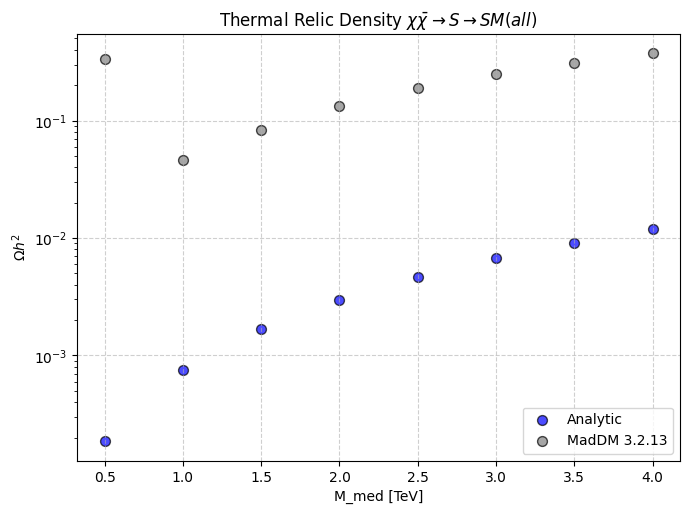

In [26]:
fig, ax  = plt.subplots(figsize=(7, 5))
plot_columns(resultados_ohm, 'M_med', "Omegah^2", xlabel='M_med [TeV]', ylabel=r"$\Omega h^2$", log=True, color='blue', label='Analytic', fig = fig, ax = ax)
plot_columns(maddm_results, 'M_med', "Omegah^2", xlabel='M_med [TeV]', ylabel=r"$\Omega h^2$", log=True, color='gray', label='MadDM 3.2.13', fig = fig, ax = ax )

ax.legend()

ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
ax.set_title(r'Thermal Relic Density $\chi \bar \chi \to S \to SM(all)$')
fig.show()
fig.show()

In [145]:
binsize_ohm = 20
dM = 1/binsize_ohm 
dmx = 0.5/binsize_ohm 
#Mediator mass [Tev] # 
Mmed_min = 0.0001
Mmed_max = 5.1
Mmed_arr = np.linspace(Mmed_min, Mmed_max, binsize_ohm)

# DM particle mass [Tev] #
mx_min = 0.0001
mx_max = 2.6
mx_arr = np.linspace(mx_min, mx_max, binsize_ohm)

# Define a grid
Mmed_grid_ohm, mx_grid_ohm = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot
gx = 1
gsm = 0.25

results_ohm = Ohm_numerical(0, Mmed_grid_ohm, mx_grid_ohm, gsm, gx, 'fermion')

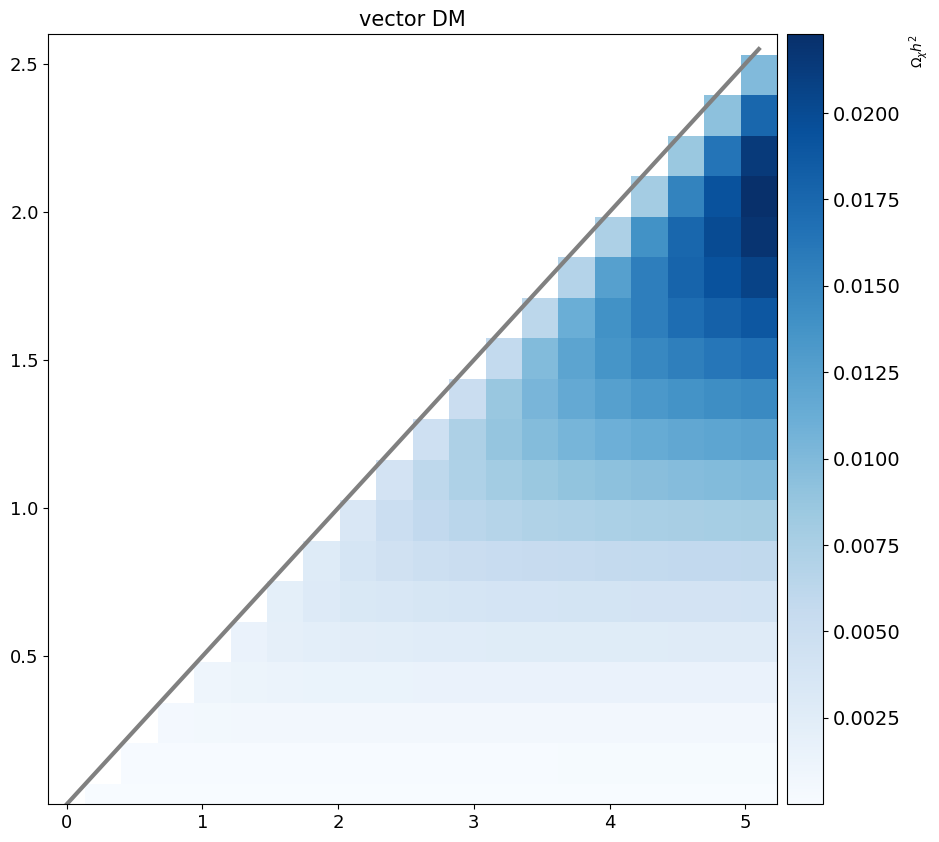

In [146]:
#import app.utils.colorb_2D as cb2d

#cb2d.cb_mass('process', f'massxmass-ISR_gr_{1}', sigmaz, omegarelic_mass, newdm_list, gr0, data_object2= omegarelic_mass2, folder = '../figures/vector-plots', fix_scale=True, cmap=new_cmap_ee, vmin=10**-4, vmax=10**10, figsize=(8, 6))


fig = plt.figure(figsize=(10,10))
ax = ImageGrid(fig, 111,          # as in plt.subplot(111)
        nrows_ncols=(1,1),
        axes_pad=(0.30, 0.0),
        share_all=True,
        cbar_location="right",
        cbar_mode="single",
        cbar_size="5%",
        cbar_pad=0.10,
        aspect=False
        )

fignumber = 0
cmap = 'Blues'
fsize = 10
scale = colors.LogNorm()
ax[fignumber].set_ylim(mx_grid_ohm[0][0], mx_grid_ohm[-1][0]) ## plot 'resolution'
im = ax[fignumber].pcolormesh(Mmed_grid_ohm, mx_grid_ohm, results_ohm, cmap=cmap, rasterized=True) ##sessão de choque convertida para fb
# Colorbar
ax[fignumber].cax.cla()
cb = colorb.Colorbar(ax[fignumber].cax, im, )
#ax[fignumber].cax.toggle_label(True)
cb.set_label(r'$\Omega_{\chi} h^2 $', fontsize = fsize, loc='top')  ## color bar label 
cb.ax.tick_params(labelsize=fsize+4)
x1, y1 = [Mmed_grid_ohm[0][0], Mmed_grid_ohm[0][-1]], [Mmed_grid_ohm[0][0]/2, Mmed_grid_ohm[0][-1]/2]
ab, = ax[fignumber].plot(x1, y1, linewidth=3, color='grey', linestyle='solid', label=r'${m_\chi } = {M_{med} }/2$', rasterized=True)
textstr = r"""$g_{SM} = %1.2f$, $g_{\chi} = %1.0f$""" %(0.25, gp.gx0)



ax[fignumber].set_title(f'{dm_type} DM', fontsize = fsize+5)
ax[fignumber].tick_params(axis="x", labelsize=fsize+3)
ax[0].tick_params(axis="y", labelsize=fsize+3)

### FORMAÇÃO DA LEGENDA (PERFEITA)
#plt.subplots_adjust(right=0.76)
#ax[fignumber].set_xlim(Mmed_grid_ohm[0][0], Mmed_grid_ohm[0][-1]) ## plot 'resolution'
#artists1, labels1 = countour_relic.legend_elements()
# labels1[0] = r'${\Omega _\chi }{h^2} \geq 0.120$ (PLANCK 2018)' 
# current_handles, current_labels = plt.gca().get_legend_handles_labels()
# artists1.extend(current_handles)
# labels1.extend(current_labels)
# artists1[0]._hatch = "\\\\\\\ "
# #artists1[0].xy = [x00, y00]
# artists1[0]._linestyle = 'dashed'
# artists1[0]._dashes = True
# artists1[0]._linewidth = 2.0
# artists1[0]._edgecolor = (0.0, 0.0, 0.0, 1.0)

# LEG =  ax[0].legend(artists1, labels1, loc='upper left', fontsize = fsize-2.5)
# LEG.get_frame().set_alpha(0.01)

In [135]:
results_ohm

array([[           nan, 9.30920614e-11, 9.30920659e-11, 9.30920668e-11,
        9.30920671e-11, 9.30920672e-11, 9.30920673e-11, 9.30920673e-11,
        9.30920674e-11, 9.30920674e-11],
       [           nan,            nan, 6.63462104e-04, 7.28956589e-04,
        7.50531932e-04, 7.60311463e-04, 7.65571601e-04, 7.68725969e-04,
        7.70766397e-04, 7.72162206e-04],
       [           nan,            nan,            nan, 2.23546570e-03,
        2.65305768e-03, 2.82548344e-03, 2.91487490e-03, 2.96747510e-03,
        3.00112195e-03, 3.02397414e-03],
       [           nan,            nan,            nan,            nan,
        4.36054478e-03, 5.45733938e-03, 5.96878675e-03, 6.25697068e-03,
        6.43711000e-03, 6.55775501e-03],
       [           nan,            nan,            nan,            nan,
                   nan, 6.85745810e-03, 8.94079247e-03, 9.98691347e-03,
        1.06106493e-02, 1.10178661e-02],
       [           nan,            nan,            nan,            nan,
   

In [61]:
len(Mmed_grid_ohm)

30

In [ ]:
binsize_ohm = 300
dM = 1/binsize_ohm 
dmx = 0.5/binsize_ohm 
#Mediator mass [Tev] # 
Mmed_min = 0.0001
Mmed_max = 5.1
Mmed_arr = np.linspace(Mmed_min, Mmed_max, binsize_ohm)

# DM particle mass [Tev] #
mx_min = 0.0001
mx_max = 2.6
mx_arr = np.linspace(mx_min, mx_max, binsize_ohm)

# Define a grid
Mmed_grid_ohm, mx_grid_ohm = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot

print('Doing mass x mass...')
omegarelic_mass = {}

process = 'qq'
Nf_x = gp.Nf_ee if process == 'ee' else gp.Nf_qq
gr0 = gp.gr0_e if process == 'ee' else gp.gr0_q
gr0 = 0.1

for gr_i in [0.1, 0.25]:
    for fignumber, dm_type in enumerate(newdm_list):


        print(f'Doing {dm_type}')
        param_lst = [Mmed_grid_ohm**2, gp.me, Mmed_grid_ohm, mx_grid_ohm, gr_i, gr_i, gp.gx0, dm_type, Nf_x]
        omegarelic_mass[f'{dm_type}'] = {}
        
        #if dmname == 'Vector':
        #omegarelic_mass[f'{dmname}']['data'] = ohm.Ohm_numerical(Mmed_grid_ohm**2, gp.me, Mmed_grid_ohm, mx_grid_ohm, gr0, gr0, gp.gx0, dmname, Nf_x) #super_naive
        omegarelic_mass[f'{dm_type}']['data'] = ohm.super_naive(4*mx_grid_ohm**2, gp.me, Mmed_grid_ohm, mx_grid_ohm, gr_i, gr_i, gp.gx0, dm_type, Nf_x)
        #else: 
        #    omegarelic_mass[f'{dmname}']['data'] = omegarelic_mass_old[f'{dmname}']

        omegarelic_mass[f'{dm_type}']['params'] = dict(zip(['s', 'mq', 'Mmed', 'mx', 'gr', 'gl', 'gx', 'dmname', 'Nf'], param_lst))
        # saves the computed data for that DM scenario
        gp.save_obj(omegarelic_mass[f'{dm_type}'], f'./myruns/{today}_supernaive_omegarelic_mass_{process}_{dm_type}_binsize_{binsize_ohm}_gr_{gr0}.pkl')
        print(f'Done for {dm_type}')

#gp.save_obj(omegarelic_mass, f'../myruns/{today}_omegarelic_mass_ee_{dmname}_binsize_{binsize_ohm}.pkl')